In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import os

# Check what directory you're currently in
print(os.getcwd())

# Check what's inside the data folder
print(os.listdir('data/'))

/Users/apple/CustomerChurn
['ecomerce_data_E_Comm.csv']


In [3]:
df = pd.read_csv('data/ecomerce_data_E_Comm.csv')

In [4]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [5]:
df.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [7]:
((df['Churn'] == 1).sum() / 5630) * 100

16.838365896980463

In [8]:
#columns with empty values
# tenure but don't have the parameter years, months => filled 0 in empty places. since those customers must have just started.
# warehouse to home => in kms? if yes how to fill the empty values => It should be filled with median distance w.r.to tier the city belongs to
# hourse spend on app => can we do mean for 255 customers => mean would skewd data, instead filled with median value
# OrderAmountHikeFromlastYear percentage wise so if higher the percetange means lesser chances of churn? also how to fill empty data =>
# couponused empty values how to fill? more coupon means lesser chances of churn?
# orderCount how to fill empty? populating it with 0 means including bias?
# days since last order if more meanning more chances of churn how to fill empty values?

In [9]:
#are divorced people more inclined to shopping? compare to married?
(df['MaritalStatus']).value_counts()

MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64

In [13]:
df.shape

(5630, 20)

In [14]:
df['PreferredLoginDevice'].value_counts()

PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

In [16]:
df['PreferredLoginDevice'].value_counts()

,count
PreferredLoginDevice,
Mobile Phone,2765
Computer,1634
Phone,1231


In [15]:
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'Mobile Phone': 'Phone', 'Phone':'Phone'})

In [16]:
df['PreferredLoginDevice'].value_counts()

PreferredLoginDevice
Phone       3996
Computer    1634
Name: count, dtype: int64

In [17]:
df['PreferredPaymentMode'].value_counts()

PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

In [18]:
df['PreferredPaymentMode']=df['PreferredPaymentMode'].replace({'CC':'Credit Card', 'Credit Card':'Credit Card'})

In [19]:
df['PreferredPaymentMode'].value_counts()

PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
UPI                  414
COD                  365
Cash on Delivery     149
Name: count, dtype: int64

In [20]:
df['CouponUsed'].value_counts()

CouponUsed
1.0     2105
2.0     1283
0.0     1030
3.0      327
4.0      197
5.0      129
6.0      108
7.0       89
8.0       42
10.0      14
9.0       13
11.0      12
12.0       9
13.0       8
14.0       5
16.0       2
15.0       1
Name: count, dtype: int64

<Axes: xlabel='CouponUsed', ylabel='count'>

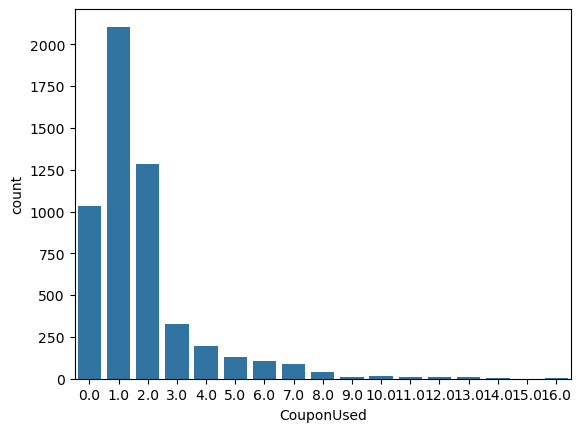

In [21]:
sns.countplot(x='CouponUsed', data=df)

In [22]:
df.groupby('CouponUsed')['Churn'].agg(['mean','count'])

,mean,count
CouponUsed,,
0.0,0.180583,1030
1.0,0.179572,2105
2.0,0.173032,1283
3.0,0.140673,327
4.0,0.152284,197
5.0,0.178295,129
6.0,0.166667,108
7.0,0.202247,89
8.0,0.214286,42


In [23]:
df.isna().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [24]:
df.groupby('CityTier')['WarehouseToHome'].agg(['median','mean','max','min'])

,median,mean,max,min
CityTier,,,,
1,13.0,15.597399,36.0,5.0
2,13.0,14.978632,33.0,6.0
3,14.0,15.818991,127.0,5.0


In [25]:
df['Tenure_empty'] = df['Tenure'].fillna(0)
#filling 0 data at empty places

In [26]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_empty
0,50001,1,4.0,Phone,3,6.0,Debit Card,Female,3.0,3,...,2,Single,9,1,11.0,1.0,1.0,5.0,160,4.0
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,...,3,Single,7,1,15.0,0.0,1.0,0.0,121,0.0
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,...,3,Single,6,1,14.0,0.0,1.0,3.0,120,0.0
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,...,5,Single,8,0,23.0,0.0,1.0,3.0,134,0.0
4,50005,1,0.0,Phone,1,12.0,Credit Card,Male,NaN,3,...,5,Single,3,0,11.0,1.0,1.0,3.0,130,0.0


In [27]:
print('original variance :', df['Tenure'].var())
print('new col with 0 added values variance :', df['Tenure_empty'].var())

original variance : 73.22637326107377
new col with 0 added values variance : 74.43351904167878


In [29]:
df[['CityTier','WarehouseToHome']].sample(20)

,CityTier,WarehouseToHome
1932,1,17.0
1801,3,13.0
2619,3,35.0
4965,3,16.0
1470,1,NaN
1817,1,6.0
662,1,8.0
3047,3,7.0
3165,3,35.0
2130,1,26.0


In [36]:
df['WarehouseToHome_empty'] = df['WarehouseToHome'].fillna(df.groupby('CityTier')['WarehouseToHome'].transform('median'))

In [37]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_empty,WarehouseToHome_empty
0,50001,1,4.0,Phone,3,6.0,Debit Card,Female,3.0,3,...,Single,9,1,11.0,1.0,1.0,5.0,160,4.0,6.0
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,...,Single,7,1,15.0,0.0,1.0,0.0,121,0.0,8.0
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,...,Single,6,1,14.0,0.0,1.0,3.0,120,0.0,30.0
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,...,Single,8,0,23.0,0.0,1.0,3.0,134,0.0,15.0
4,50005,1,0.0,Phone,1,12.0,Credit Card,Male,NaN,3,...,Single,3,0,11.0,1.0,1.0,3.0,130,0.0,12.0


In [38]:
print('original variance :', df['WarehouseToHome'].var())
print('new col with adding median values per citytier added values variance :', df['WarehouseToHome_empty'].var())

original variance : 72.78606886234714
new col with adding median values per citytier added values variance : 69.81077252505042


In [39]:
df.isna().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
Tenure_empty                     0
WarehouseToHome_empty            0
dtype: int64

In [40]:
df.groupby('PreferredLoginDevice')['HourSpendOnApp'].agg(['mean','median','max','min'])

,mean,median,max,min
PreferredLoginDevice,,,,
Computer,2.908916,3.0,4.0,0.0
Phone,2.940776,3.0,5.0,0.0


In [41]:
df['HourSpendOnApp_empty'] = df['HourSpendOnApp'].fillna(df['HourSpendOnApp'].median())

In [42]:
print('original variance :', df['HourSpendOnApp'].var())
print('new col with adding median values per citytier added values variance :', df['HourSpendOnApp_empty'].var())

original variance : 0.521176932863616
new col with adding median values per citytier added values variance : 0.4977697643546874


In [43]:
df.isna().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
Tenure_empty                     0
WarehouseToHome_empty            0
HourSpendOnApp_empty             0
dtype: int64

In [44]:
#columns with empty values
# tenure but don't have the parameter years, months => filled 0 in empty places. since those customers must have just started.
# warehouse to home => in kms? if yes how to fill the empty values => It should be filled with median distance w.r.to tier the city belongs to
# hourse spend on app => can we do mean for 255 customers => mean would skewd data, instead filled with median value
# OrderAmountHikeFromlastYear percentage wise so if higher the percetange means lesser chances of churn? also how to fill empty data => filled with median
# couponused empty values how to fill? more coupon means lesser chances of churn? => filled with 0 it could mean no coupon used
# orderCount how to fill empty? populating it with 0 means including bias? =>
# days since last order if more meanning more chances of churn how to fill empty values?

In [45]:
df.groupby('CityTier')['OrderAmountHikeFromlastYear'].agg(['median','max','min'])

,median,max,min
CityTier,,,
1,15.0,26.0,11.0
2,14.0,24.0,11.0
3,15.0,26.0,11.0


In [46]:
df['OrderAmountHikeFromlastYear_empty'] = df['OrderAmountHikeFromlastYear'].fillna(df['OrderAmountHikeFromlastYear'].median())

In [47]:
print('original variance :', df['OrderAmountHikeFromlastYear'].var())
print('new col with adding median values per citytier added values variance :', df['OrderAmountHikeFromlastYear_empty'].var())

original variance : 13.509193386860618
new col with adding median values per citytier added values variance : 12.895695123609087


In [48]:
df.isna().sum()

CustomerID                             0
Churn                                  0
Tenure                               264
PreferredLoginDevice                   0
CityTier                               0
WarehouseToHome                      251
PreferredPaymentMode                   0
Gender                                 0
HourSpendOnApp                       255
NumberOfDeviceRegistered               0
PreferedOrderCat                       0
SatisfactionScore                      0
MaritalStatus                          0
NumberOfAddress                        0
Complain                               0
OrderAmountHikeFromlastYear          265
CouponUsed                           256
OrderCount                           258
DaySinceLastOrder                    307
CashbackAmount                         0
Tenure_empty                           0
WarehouseToHome_empty                  0
HourSpendOnApp_empty                   0
OrderAmountHikeFromlastYear_empty      0
dtype: int64

In [49]:
df['OrderAmountHikeFromlastYear'].value_counts()

OrderAmountHikeFromlastYear
14.0    750
13.0    741
12.0    728
15.0    542
11.0    391
16.0    333
18.0    321
19.0    311
17.0    297
20.0    243
21.0    190
22.0    184
23.0    144
24.0     84
25.0     73
26.0     33
Name: count, dtype: int64

<Axes: xlabel='OrderAmountHikeFromlastYear', ylabel='count'>

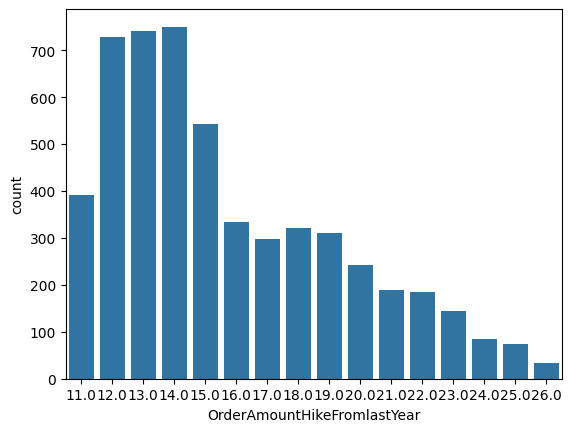

In [45]:
sns.countplot(x='OrderAmountHikeFromlastYear', data=df)

<Axes: xlabel='Churn', ylabel='OrderAmountHikeFromlastYear'>

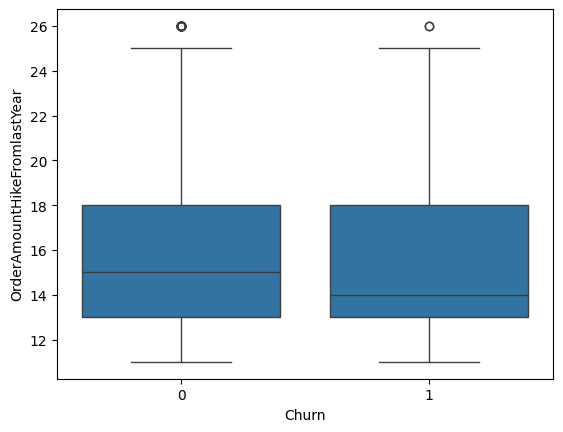

In [46]:
sns.boxplot(data=df, x='Churn', y='OrderAmountHikeFromlastYear')

In [50]:
df['CouponUsed_empty'] = df['CouponUsed'].fillna(0)

In [51]:
print('original variance :', df['CouponUsed'].var())
print('new col with adding median values per citytier added values variance :', df['CouponUsed_empty'].var())

original variance : 3.5895904282609443
new col with adding median values per citytier added values variance : 3.5594414487017834


In [52]:
df.isna().sum()

CustomerID                             0
Churn                                  0
Tenure                               264
PreferredLoginDevice                   0
CityTier                               0
WarehouseToHome                      251
PreferredPaymentMode                   0
Gender                                 0
HourSpendOnApp                       255
NumberOfDeviceRegistered               0
PreferedOrderCat                       0
SatisfactionScore                      0
MaritalStatus                          0
NumberOfAddress                        0
Complain                               0
OrderAmountHikeFromlastYear          265
CouponUsed                           256
OrderCount                           258
DaySinceLastOrder                    307
CashbackAmount                         0
Tenure_empty                           0
WarehouseToHome_empty                  0
HourSpendOnApp_empty                   0
OrderAmountHikeFromlastYear_empty      0
CouponUsed_empty

In [53]:
df['OrderCount_empty'] = df['OrderCount'].fillna(0)

In [54]:
print('original variance :', df['OrderCount'].var())
print('new col with adding median values per citytier added values variance :', df['OrderCount_empty'].var())

original variance : 8.641715845818785
new col with adding median values per citytier added values variance : 8.64133715688837


In [55]:
df.isna().sum()

CustomerID                             0
Churn                                  0
Tenure                               264
PreferredLoginDevice                   0
CityTier                               0
WarehouseToHome                      251
PreferredPaymentMode                   0
Gender                                 0
HourSpendOnApp                       255
NumberOfDeviceRegistered               0
PreferedOrderCat                       0
SatisfactionScore                      0
MaritalStatus                          0
NumberOfAddress                        0
Complain                               0
OrderAmountHikeFromlastYear          265
CouponUsed                           256
OrderCount                           258
DaySinceLastOrder                    307
CashbackAmount                         0
Tenure_empty                           0
WarehouseToHome_empty                  0
HourSpendOnApp_empty                   0
OrderAmountHikeFromlastYear_empty      0
CouponUsed_empty

In [56]:
df.groupby('CityTier')['DaySinceLastOrder'].agg(['median','min','max'])

,median,min,max
CityTier,,,
1,3.0,0.0,31.0
2,3.0,0.0,11.0
3,3.0,0.0,46.0


In [57]:
df['DaySinceLastOrder_empty'] = df['DaySinceLastOrder'].fillna(df['DaySinceLastOrder'].median())

In [58]:
print('original variance :', df['DaySinceLastOrder'].var())
print('new col with adding median values per citytier added values variance :', df['DaySinceLastOrder_empty'].var())

original variance : 13.354881989152904
new col with adding median values per citytier added values variance : 12.749366749897344


In [59]:
df.isna().sum()

CustomerID                             0
Churn                                  0
Tenure                               264
PreferredLoginDevice                   0
CityTier                               0
WarehouseToHome                      251
PreferredPaymentMode                   0
Gender                                 0
HourSpendOnApp                       255
NumberOfDeviceRegistered               0
PreferedOrderCat                       0
SatisfactionScore                      0
MaritalStatus                          0
NumberOfAddress                        0
Complain                               0
OrderAmountHikeFromlastYear          265
CouponUsed                           256
OrderCount                           258
DaySinceLastOrder                    307
CashbackAmount                         0
Tenure_empty                           0
WarehouseToHome_empty                  0
HourSpendOnApp_empty                   0
OrderAmountHikeFromlastYear_empty      0
CouponUsed_empty

In [60]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_empty,WarehouseToHome_empty,HourSpendOnApp_empty,OrderAmountHikeFromlastYear_empty,CouponUsed_empty,OrderCount_empty,DaySinceLastOrder_empty
0,50001,1,4.0,Phone,3,6.0,Debit Card,Female,3.0,3,...,1.0,5.0,160,4.0,6.0,3.0,11.0,1.0,1.0,5.0
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,...,1.0,0.0,121,0.0,8.0,3.0,15.0,0.0,1.0,0.0
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,...,1.0,3.0,120,0.0,30.0,2.0,14.0,0.0,1.0,3.0
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,...,1.0,3.0,134,0.0,15.0,2.0,23.0,0.0,1.0,3.0
4,50005,1,0.0,Phone,1,12.0,Credit Card,Male,NaN,3,...,1.0,3.0,130,0.0,12.0,3.0,11.0,1.0,1.0,3.0


In [61]:
df.shape

(5630, 27)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   CustomerID                         5630 non-null   int64  
 1   Churn                              5630 non-null   int64  
 2   Tenure                             5366 non-null   float64
 3   PreferredLoginDevice               5630 non-null   object 
 4   CityTier                           5630 non-null   int64  
 5   WarehouseToHome                    5379 non-null   float64
 6   PreferredPaymentMode               5630 non-null   object 
 7   Gender                             5630 non-null   object 
 8   HourSpendOnApp                     5375 non-null   float64
 9   NumberOfDeviceRegistered           5630 non-null   int64  
 10  PreferedOrderCat                   5630 non-null   object 
 11  SatisfactionScore                  5630 non-null   int64

In [63]:
df['Tenure'] = df['Tenure_empty']

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   CustomerID                         5630 non-null   int64  
 1   Churn                              5630 non-null   int64  
 2   Tenure                             5630 non-null   float64
 3   PreferredLoginDevice               5630 non-null   object 
 4   CityTier                           5630 non-null   int64  
 5   WarehouseToHome                    5379 non-null   float64
 6   PreferredPaymentMode               5630 non-null   object 
 7   Gender                             5630 non-null   object 
 8   HourSpendOnApp                     5375 non-null   float64
 9   NumberOfDeviceRegistered           5630 non-null   int64  
 10  PreferedOrderCat                   5630 non-null   object 
 11  SatisfactionScore                  5630 non-null   int64

In [65]:
df['WarehouseToHome'] = df['WarehouseToHome_empty']
df['HourSpendOnApp'] = df['HourSpendOnApp_empty']
df['OrderAmountHikeFromlastYear'] = df['OrderAmountHikeFromlastYear_empty']
df['CouponUsed'] = df['CouponUsed_empty']
df['OrderCount'] = df['OrderCount_empty']
df['DaySinceLastOrder'] = df['DaySinceLastOrder_empty']

In [66]:
df.shape

(5630, 27)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   CustomerID                         5630 non-null   int64  
 1   Churn                              5630 non-null   int64  
 2   Tenure                             5630 non-null   float64
 3   PreferredLoginDevice               5630 non-null   object 
 4   CityTier                           5630 non-null   int64  
 5   WarehouseToHome                    5630 non-null   float64
 6   PreferredPaymentMode               5630 non-null   object 
 7   Gender                             5630 non-null   object 
 8   HourSpendOnApp                     5630 non-null   float64
 9   NumberOfDeviceRegistered           5630 non-null   int64  
 10  PreferedOrderCat                   5630 non-null   object 
 11  SatisfactionScore                  5630 non-null   int64

<Axes: >

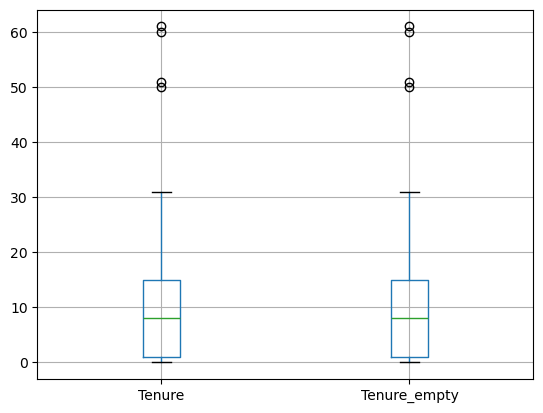

In [68]:
df[['Tenure','Tenure_empty']].boxplot()

In [69]:
df.isnull().sum()

CustomerID                           0
Churn                                0
Tenure                               0
PreferredLoginDevice                 0
CityTier                             0
WarehouseToHome                      0
PreferredPaymentMode                 0
Gender                               0
HourSpendOnApp                       0
NumberOfDeviceRegistered             0
PreferedOrderCat                     0
SatisfactionScore                    0
MaritalStatus                        0
NumberOfAddress                      0
Complain                             0
OrderAmountHikeFromlastYear          0
CouponUsed                           0
OrderCount                           0
DaySinceLastOrder                    0
CashbackAmount                       0
Tenure_empty                         0
WarehouseToHome_empty                0
HourSpendOnApp_empty                 0
OrderAmountHikeFromlastYear_empty    0
CouponUsed_empty                     0
OrderCount_empty         

In [70]:
df = df.drop(columns=['Tenure_empty','WarehouseToHome_empty','HourSpendOnApp_empty','OrderAmountHikeFromlastYear_empty','CouponUsed_empty','OrderCount_empty','DaySinceLastOrder_empty'])

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5630 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5630 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5630 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [72]:
df.shape

(5630, 20)

In [73]:
df.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [74]:
df['Churn'].value_counts(normalize=True)

Churn
0    0.831616
1    0.168384
Name: proportion, dtype: float64

In [76]:
#there are some categorical values those need to convert to numbers

In [75]:
category = df.select_dtypes(include=['object','category'])

In [76]:
category

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
0,Phone,Debit Card,Female,Laptop & Accessory,Single
1,Phone,UPI,Male,Mobile,Single
2,Phone,Debit Card,Male,Mobile,Single
3,Phone,Debit Card,Male,Laptop & Accessory,Single
4,Phone,Credit Card,Male,Mobile,Single
...,...,...,...,...,...
5625,Computer,Credit Card,Male,Laptop & Accessory,Married
5626,Phone,Credit Card,Male,Fashion,Married
5627,Phone,Debit Card,Male,Laptop & Accessory,Married
5628,Computer,Credit Card,Male,Laptop & Accessory,Married


In [77]:
category['PreferredLoginDevice'].value_counts()

PreferredLoginDevice
Phone       3996
Computer    1634
Name: count, dtype: int64

In [84]:
category['PreferredPaymentMode'].value_counts()
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({'COD': 'COD', 'Cash on Delivery': 'COD'})
category['PreferredPaymentMode'] = df['PreferredPaymentMode']
category['PreferredPaymentMode'].value_counts()

PreferredPaymentMode
Debit Card     2314
Credit Card    1774
E wallet        614
COD             514
UPI             414
Name: count, dtype: int64

In [85]:
category['PreferedOrderCat'].value_counts()

PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

In [84]:
category['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2986
Single,1796
Divorced,848


In [85]:
category['Gender'].value_counts()

,count
Gender,
Male,3384
Female,2246


<Axes: xlabel='PreferedOrderCat'>

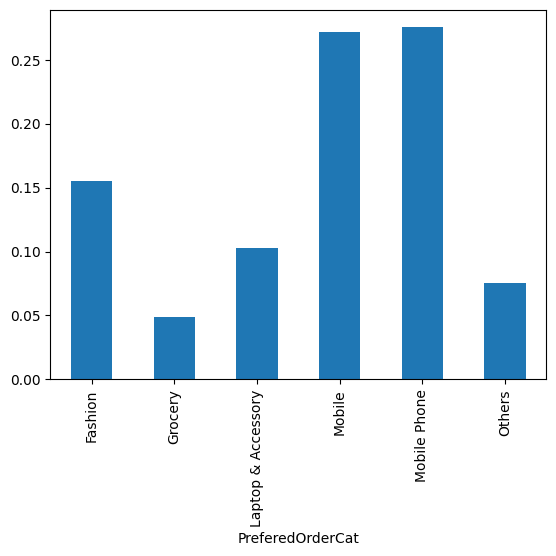

In [89]:
df.groupby('PreferedOrderCat')['Churn'].mean().plot(kind='bar')

In [86]:
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile':'Phone', 'Mobile Phone':'Phone'})

In [87]:
df['PreferedOrderCat'].value_counts()

PreferedOrderCat
Phone                 2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64

In [88]:
df['SatisfactionScore'].value_counts()

SatisfactionScore
3    1698
1    1164
5    1108
4    1074
2     586
Name: count, dtype: int64

In [112]:
df['Complain'].value_counts()

,count
Complain,
0,4026
1,1604


In [113]:
df['NumberOfAddress'].value_counts()

,count
NumberOfAddress,
2,1369
3,1278
4,588
5,571
6,382
1,371
8,280
7,256
9,239


In [98]:
df.info()
df['NumberOfDeviceRegistered'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5630 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5630 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5630 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

NumberOfDeviceRegistered
4    2377
3    1699
5     881
2     276
1     235
6     162
Name: count, dtype: int64

In [89]:
pip install ydata-profiling

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 1.0 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 665.7/665.7 kB 7.1 MB/s eta 0:00:00
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typing_extensions-4.11.0:
      Successfully uninstalled typing_extensions-4.11.0
  Attempting uninstall: PyYAML
    Found existing installation: PyYAML 6.0.1
    Uninstalling PyYAML-6.0.1:
      Successfully uninstalled PyYAML-6.0.1
  Attempting uninstall: jinja2
    Found existing installation: Jinja2 3.1.4
    Uninstalling Jinja2-3.1.4:
      Successfully uninstalled Jinja2-3.1.4
Note: you may need to restart the kernel to use updated packages.


In [93]:
pip install --upgrade ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [95]:
from ydata_profiling import ProfileReport
rep = pd.read_csv('data/ecomerce_data_E_Comm.csv')
profile = ProfileReport(rep, title="Churn EDA Report", explorative=True)
profile.to_file("churn_eda_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 297.57it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [95]:
from sklearn.model_selection import train_test_split

In [99]:
df = df.drop(columns=['CustomerID'])

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Churn                        5630 non-null   int64  
 1   Tenure                       5630 non-null   float64
 2   PreferredLoginDevice         5630 non-null   object 
 3   CityTier                     5630 non-null   int64  
 4   WarehouseToHome              5630 non-null   float64
 5   PreferredPaymentMode         5630 non-null   object 
 6   Gender                       5630 non-null   object 
 7   HourSpendOnApp               5630 non-null   float64
 8   NumberOfDeviceRegistered     5630 non-null   int64  
 9   PreferedOrderCat             5630 non-null   object 
 10  SatisfactionScore            5630 non-null   int64  
 11  MaritalStatus                5630 non-null   object 
 12  NumberOfAddress              5630 non-null   int64  
 13  Complain          

In [103]:
df.to_csv('refined_output.csv', index=False)

In [104]:
rep = pd.read_csv('refined_output.csv')
profile = ProfileReport(rep, title="Churn refined", explorative=True)
profile.to_file("churn_refined_output_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 19/19 [00:00<00:00, 316237.21it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

EDA notes: 
CashbackAmount is highly correlated with PreferredOrderCat and tenure
CouponUsed is highly correlated with the OrderCount


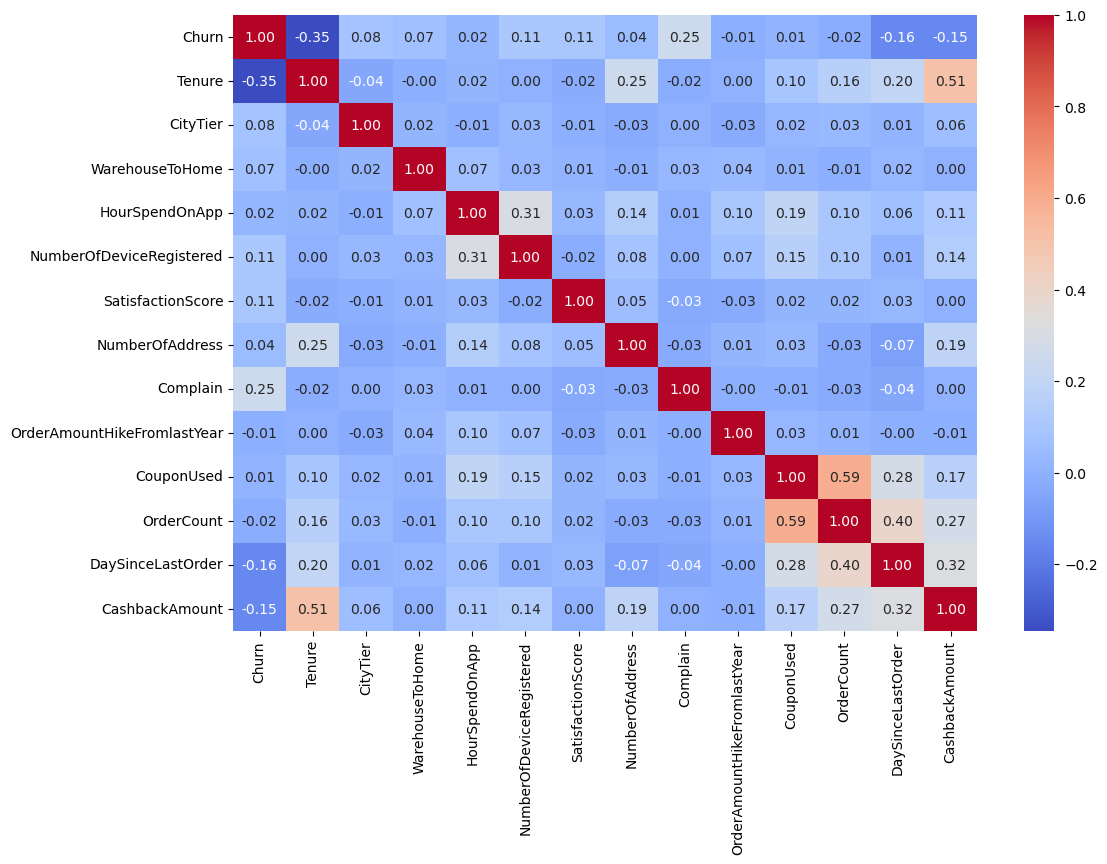

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_mat = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

<Axes: xlabel='SatisfactionScore'>

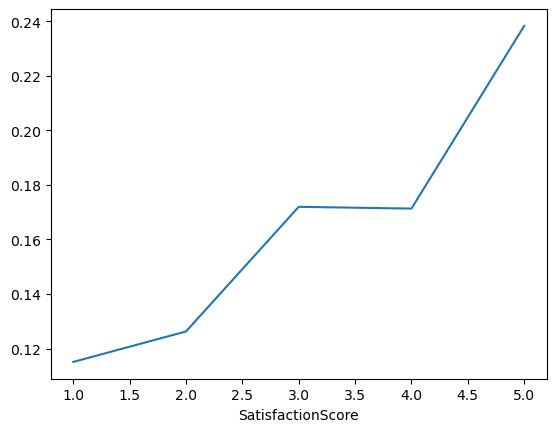

In [112]:
df.groupby("SatisfactionScore")['Churn'].mean().plot()

In [109]:
df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

Churn                          1.000000
Complain                       0.250188
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.067309
NumberOfAddress                0.043931
HourSpendOnApp                 0.018816
CouponUsed                     0.007425
OrderAmountHikeFromlastYear   -0.007075
OrderCount                    -0.015327
CashbackAmount                -0.154161
DaySinceLastOrder             -0.155871
Tenure                        -0.345374
Name: Churn, dtype: float64

In [113]:
numerical_cols = ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear','CouponUsed','OrderCount','DaySinceLastOrder','CashbackAmount']

In [ ]:
categorical_cols = ['PreferredLoginDevice','PreferredPaymentMode','Gender','PreferedOrderCat','MaritalStatus']


In [141]:
len(categorical_cols)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [143]:
X = df.drop('Churn', axis=1)

In [151]:
y = df['Churn']
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifer', LogisticRegression())
])

In [152]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [153]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Tenure', 'CityTier',
                                                   'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'SatisfactionScore',
                                                   'NumberOfAddress',
                                                   'Complain',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',
                                                   'DaySinceLastOrder',
                                                   'CashbackAmount']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['PreferredLoginDevice',
                                                   'PreferredPaymentMode',
                                                   'Gender', 'PreferedOrderCat',
                                                   'MaritalStatus'])])),
                ('classifer', LogisticRegression())])

In [154]:
predictions = clf.predict(X_test)

In [155]:
print(predictions)

[1 0 0 ... 0 0 0]


In [156]:
accuracy = accuracy_score(y_test, predictions)

In [157]:
accuracy

0.9067495559502664

In [158]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95       941
           1       0.84      0.54      0.65       185

    accuracy                           0.91      1126
   macro avg       0.88      0.76      0.80      1126
weighted avg       0.90      0.91      0.90      1126

ROC-AUC: 0.9015538386420425
[[922  19]
 [ 86  99]]
